
# Model Evaluation, Bayesian Concepts and Explainable AI

**Dataset:** Pima Indians Diabetes Dataset

This experiment evaluates a classification model using cross-validation, F1-score, Brier Score and calibration analysis. SHAP is used to understand the features influencing individual predictions.


In [17]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, brier_score_loss,
    classification_report
)
from sklearn.calibration import calibration_curve

import shap

import warnings
warnings.filterwarnings("ignore")



## 1. Load Dataset

The Pima Indians Diabetes Dataset contains 768 observations and 8 input features. The target variable is `Outcome`.


In [18]:

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:

print("Missing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Outcome"].value_counts())


Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64



## 2. Preprocessing

Some medical measurements contain zero values that are not realistic, such as zero BMI or zero glucose. They are replaced with the median of the corresponding feature.


In [20]:

features = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

X = df[features].copy()
y = df["Outcome"]

zero_columns = [
    "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI"
]

X[zero_columns] = X[zero_columns].replace(0, np.nan)
X = X.fillna(X.median())

print("Preprocessed data shape:", X.shape)
display(X.head())


Preprocessed data shape: (768, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33



## 3. Train-Test Split

The dataset is divided into training and testing sets. Stratification keeps the proportion of diabetic and non-diabetic patients similar in both sets.


In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 614
Testing samples: 154



## 4. Build Classification Model

Logistic Regression is used because it is suitable for binary classification and its probabilities can be used for calibration and Brier Score analysis.


In [22]:

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test F1-score:", round(f1_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.7078
Test F1-score: 0.5455

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154




## 5. 5-Fold Cross-Validation

Stratified 5-fold cross-validation is used to get a more reliable estimate of model performance.


In [23]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1"]
)

accuracy_scores = scores["test_accuracy"]
f1_scores = scores["test_f1"]

print("Accuracy for each fold:", np.round(accuracy_scores, 4))
print("F1-score for each fold:", np.round(f1_scores, 4))

print("\nAccuracy Mean:", round(accuracy_scores.mean(), 4))
print("Accuracy Std:", round(accuracy_scores.std(), 4))

print("\nF1 Mean:", round(f1_scores.mean(), 4))
print("F1 Std:", round(f1_scores.std(), 4))


Accuracy for each fold: [0.7727 0.7987 0.7792 0.7516 0.7647]
F1-score for each fold: [0.6392 0.6517 0.6383 0.5957 0.6604]

Accuracy Mean: 0.7734
Accuracy Std: 0.0156

F1 Mean: 0.6371
F1 Std: 0.0222



## 6. Brier Score

The Brier Score measures the difference between predicted probabilities and actual outcomes. Lower values indicate better probabilistic predictions.


In [24]:

brier = brier_score_loss(y_test, y_prob)

print("Brier Score:", round(brier, 4))


Brier Score: 0.1754



## 7. Calibration Curve

A calibration curve compares predicted probabilities with the actual fraction of positive outcomes.


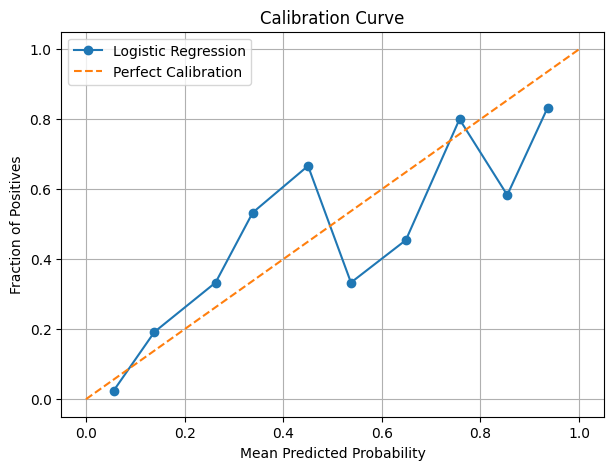

In [25]:

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()



## 8. SHAP Explainability

SHAP values show how each feature affects the prediction. Positive values push the prediction towards diabetes, while negative values push it towards non-diabetes.


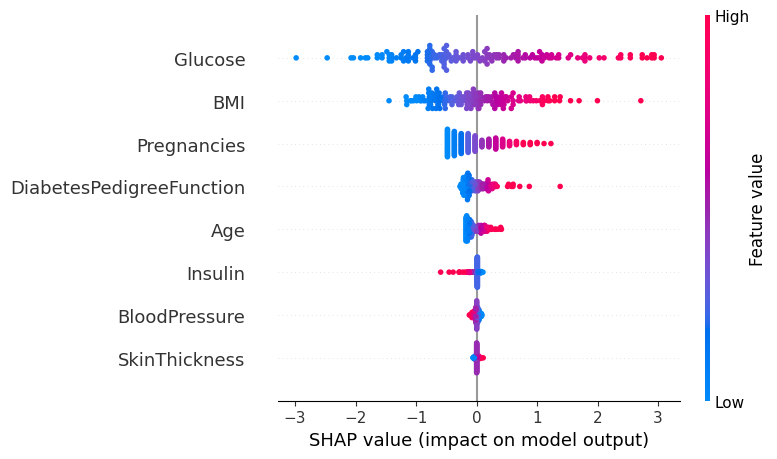

In [26]:

# Get the fitted Logistic Regression model
scaler = model.named_steps["scaler"]
classifier = model.named_steps["classifier"]

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

explainer = shap.LinearExplainer(
    classifier,
    X_train_scaled
)

shap_values = explainer(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)



## 9. SHAP Feature Importance


,Feature,Mean Absolute SHAP
1,Glucose,1.015550
5,BMI,0.566419
0,Pregnancies,0.341287
6,DiabetesPedigreeFunction,0.173990
7,Age,0.126332
4,Insulin,0.046624
2,BloodPressure,0.031152
3,SkinThickness,0.017932


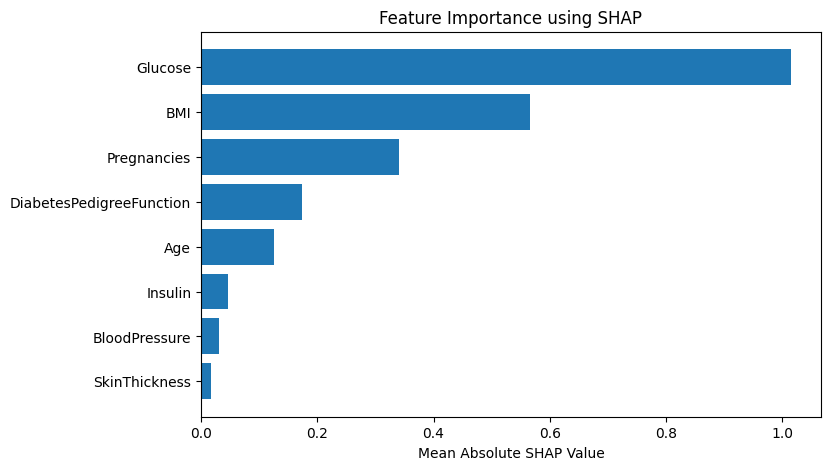

In [27]:

mean_shap = np.abs(shap_values.values).mean(axis=0)

importance = pd.DataFrame({
    "Feature": features,
    "Mean Absolute SHAP": mean_shap
}).sort_values("Mean Absolute SHAP", ascending=False)

display(importance)

plt.figure(figsize=(8, 5))
plt.barh(
    importance["Feature"][::-1],
    importance["Mean Absolute SHAP"][::-1]
)
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Feature Importance using SHAP")
plt.show()



## 10. Explain an Individual Prediction

The first test observation is selected and its SHAP values are displayed.


In [28]:

sample_index = 0

sample = X_test.iloc[[sample_index]]
actual = y_test.iloc[sample_index]
prediction = y_pred[sample_index]
probability = y_prob[sample_index]

print("Actual Outcome:", actual)
print("Predicted Outcome:", prediction)
print("Predicted Probability of Diabetes:", round(probability, 4))

individual_shap = pd.DataFrame({
    "Feature": features,
    "Value": sample.iloc[0].values,
    "SHAP Value": shap_values.values[sample_index]
})

individual_shap["Effect"] = np.where(
    individual_shap["SHAP Value"] > 0,
    "Increases diabetes prediction",
    "Decreases diabetes prediction"
)

individual_shap = individual_shap.sort_values(
    "SHAP Value",
    key=lambda x: abs(x),
    ascending=False
)

display(individual_shap)


Actual Outcome: 0
Predicted Outcome: 1
Predicted Probability of Diabetes: 0.6097


,Feature,Value,SHAP Value,Effect
1,Glucose,159.000,1.553313,Increases diabetes prediction
5,BMI,27.400,-0.518578,Decreases diabetes prediction
0,Pregnancies,7.000,0.315778,Increases diabetes prediction
6,DiabetesPedigreeFunction,0.294,-0.123011,Decreases diabetes prediction
7,Age,40.000,0.060000,Increases diabetes prediction
2,BloodPressure,64.000,0.030395,Increases diabetes prediction
4,Insulin,125.000,0.011466,Increases diabetes prediction
3,SkinThickness,29.000,0.000921,Increases diabetes prediction


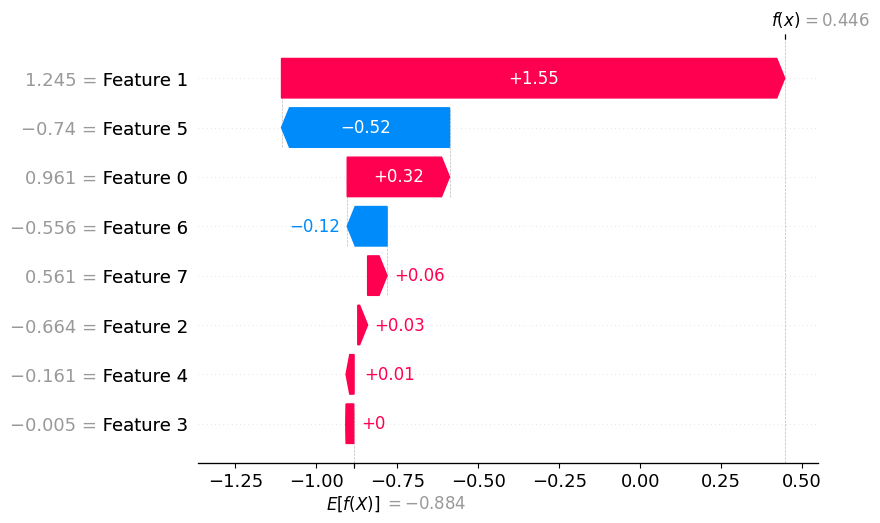

In [29]:

shap.plots.waterfall(shap_values[sample_index], max_display=8)



## 11. Final Results Summary


In [30]:

print("===== FINAL RESULTS =====")
print(f"Mean CV Accuracy : {accuracy_scores.mean():.4f}")
print(f"Std CV Accuracy  : {accuracy_scores.std():.4f}")
print(f"Mean CV F1-score : {f1_scores.mean():.4f}")
print(f"Std CV F1-score  : {f1_scores.std():.4f}")
print(f"Brier Score      : {brier:.4f}")

print("\nMost influential features:")
for _, row in importance.head(5).iterrows():
    print(f"{row['Feature']}: {row['Mean Absolute SHAP']:.4f}")


===== FINAL RESULTS =====
Mean CV Accuracy : 0.7734
Std CV Accuracy  : 0.0156
Mean CV F1-score : 0.6371
Std CV F1-score  : 0.0222
Brier Score      : 0.1754

Most influential features:
Glucose: 1.0155
BMI: 0.5664
Pregnancies: 0.3413
DiabetesPedigreeFunction: 0.1740
Age: 0.1263
